<a href="https://colab.research.google.com/github/keyonai/Practice-for-extern/blob/main/Keyonai_Enhance_a_Scanned_Document_Using_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

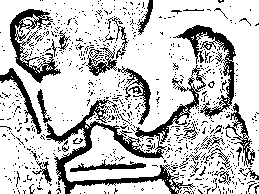

In [6]:
import cv2
from google.colab.patches import cv2_imshow # Import cv2_imshow for Colab

image_path = "noisy_image_sample.jpg"
img = cv2.imread(image_path)

if img is None:
    print(f"Error: Could not load image at {image_path}. Please ensure the file exists in the current directory or provide the correct path. You can upload the image using the file explorer icon on the left sidebar.")
else:
    gaussian = cv2.GaussianBlur(img, (5,5), 0)
    median = cv2.medianBlur(gaussian, 5)
    denoised = cv2.fastNlMeansDenoising(median, None, 30, 7, 21)
     # Convert image to grayscale for histogram equalization
    gray_img = cv2.cvtColor(denoised, cv2.COLOR_BGR2GRAY)
    hist_eq = cv2.equalizeHist(gray_img)
    thresh_adaptive = cv2.adaptiveThreshold(hist_eq, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY, 11, 2)



    # Display the combined image
    cv2_imshow(thresh_adaptive)
#take # away to download new image
    #cv2.imwrite("processed_image.jpg", thresh_adaptive)
